In [68]:

from pymongo import MongoClient
import pandas as pd

try: 
    client = MongoClient("localhost", 5001)
    print("Connected successfully!!!") 
except:
    print("Could not connect to MongoDB")

db = client["flask_db"]
activity = db.activity



Connected successfully!!!


In [69]:
project_ids = (
    "656fadd102ae94a7686aae62",
    "640e22cae918523bcee8ca5e",
    "6543b8ee4180527babd20c3a",
    "656a440644dec9f71f2dee44",
    "654682f220e7d557c7e67cff",
    "6470fc81c8542274b9582aa1"
)

project_id = project_ids[3]
#project_id = "6516fce1459696e2363e98ef"

query = {"project": project_id, "editingLines": {"$exists": True, "$ne": None}}

cursor = activity.find(query)

df = pd.DataFrame(list(cursor))
#df = df.astype({"text": str, "state": str, "line": str, "username": str, "project": str, "file": str, "message": str})

col_names = df.columns.tolist()
dtypes = df.dtypes
df.head()

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,clipboard,changes,cb
0,657cc175699d8f6253cb2f7d,1702674804994,\section{Constructing ``TenPageStories'' Datas...,"[[0, ], [4, \section{Constructing ``TenPageSto...",Copy,1,Zae Myung,656a440644dec9f71f2dee44,7_appendix.tex,"[1, 2]",Copy,"[(1,0), \section{Constructing ``TenPageStories...",NaN,NaN
1,657cc175699d8f6253cb2f7e,1702674805205,\section{Constructing ``TenPageStories'' Datas...,"[[0, \section{Constructing ``TenPageStories'' ...",Paste,2,Zae Myung,656a440644dec9f71f2dee44,7_appendix.tex,"[1, 2, 3]",Paste,\section{Constructing ``TenPageStories'' Datas...,"[(2,0) \section{Constructing ``TenPageStories'...",NaN
2,657cc176699d8f6253cb2f7f,1702674806190,\section{Constructing ``TenPageStories'' Datas...,"[[0, \section{Constructing ``TenPageStories'' ...",Typing,1,Zae Myung,656a440644dec9f71f2dee44,7_appendix.tex,"[1, 2]",Typing,NaN,"[(1,1), section{Constructing ``TenPageStories'...",NaN
3,657cc18a699d8f6253cb2f80,1702674826386,\section{Conclusion}\label{sec:conclusion}\n,"[[0, ], [4, \section{Conclusion}\label{sec:con...",Copy,1,Zae Myung,656a440644dec9f71f2dee44,6_conclusion.tex,"[1, 2]",Copy,"[(1,0), \section{Conclusion}\label{sec:conclus...",NaN,NaN
4,657cc199699d8f6253cb2f81,1702674840978,\section{Limitation}\label{sec:limitation}\n\n,"[[0, \section{Limitation}\label{sec:limitation...",Typing,2,Zae Myung,656a440644dec9f71f2dee44,7_limitations.tex,"[1, 2, 3]",Typing,NaN,"[(2,0), \n---added]",NaN


In [70]:
print("column names", col_names)
print("num rows", len(df))

print("average len", df["editingLines"].apply(len).mean())
print("median len", df["editingLines"].apply(len).median())
print("mode len", df["editingLines"].apply(len).mode().tolist())

column names ['_id', 'timestamp', 'text', 'revision', 'state', 'line', 'username', 'project', 'file', 'editingLines', 'message', 'clipboard', 'changes', 'cb']
num rows 9545
average len 59.48161341016239
median len 58.0
mode len [54]


In [71]:
print("unique files in project", df["file"].unique())

unique files in project ['7_appendix.tex' '6_conclusion.tex' '7_limitations.tex'
 '5_experimental_results.tex' '0_main.tex' '8_appendix.tex' 'custom.bib'
 'figures' '1_introduction.tex' '2_related_work.tex'
 '3_hierarchical_structures.tex' '4_revealing_key_patterns.tex'
 '6_experimental_results.tex' '7_conclusion.tex' '8_limitations.tex'
 '9_appendix.tex' '5_experimental_setup.tex' 'acl_version' 'main.tex'
 'acl_natbib.bst' 'acl.sty' 'backup' 'acl']


In [72]:
df1 = df["username"].value_counts().sort_values()
df["line_counts"] = df["editingLines"].apply(len)

df2 = df.groupby(["username"])["line_counts"].sum().sort_values()
print(df.head())

print(df1)
print(df2)


                        _id      timestamp  \
0  657cc175699d8f6253cb2f7d  1702674804994   
1  657cc175699d8f6253cb2f7e  1702674805205   
2  657cc176699d8f6253cb2f7f  1702674806190   
3  657cc18a699d8f6253cb2f80  1702674826386   
4  657cc199699d8f6253cb2f81  1702674840978   

                                                text  \
0  \section{Constructing ``TenPageStories'' Datas...   
1  \section{Constructing ``TenPageStories'' Datas...   
2  \section{Constructing ``TenPageStories'' Datas...   
3       \section{Conclusion}\label{sec:conclusion}\n   
4     \section{Limitation}\label{sec:limitation}\n\n   

                                            revision   state line   username  \
0  [[0, ], [4, \section{Constructing ``TenPageSto...    Copy    1  Zae Myung   
1  [[0, \section{Constructing ``TenPageStories'' ...   Paste    2  Zae Myung   
2  [[0, \section{Constructing ``TenPageStories'' ...  Typing    1  Zae Myung   
3  [[0, ], [4, \section{Conclusion}\label{sec:con...    Copy    1 

['Zae Myung' 'Zae']


/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



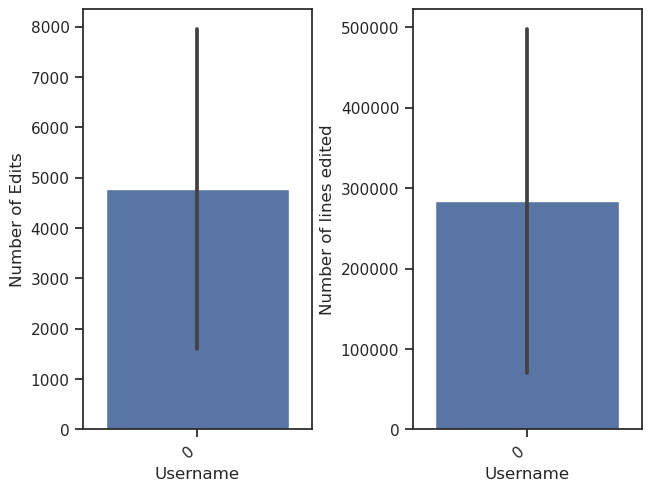

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import colorcet as cc

sns.set_theme(style="ticks")

print(df["username"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True) 

ax1 = sns.barplot(df1, ax=ax1)
ax1.set(xlabel='Username', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")


ax2 = sns.barplot(df2, ax=ax2)
ax2.set(xlabel="Username", ylabel="Number of lines edited")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_edits_fig.png")




In [74]:
def count_op(op, revision):
    count = 0
    
    for l in revision:
        curr_op = l[0]

        if (op is None):
            count += len(l[1])
        if curr_op == op:
            count += op * len(l[1])

    return count
        

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/tmp/ipykernel_1663737/45329987.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



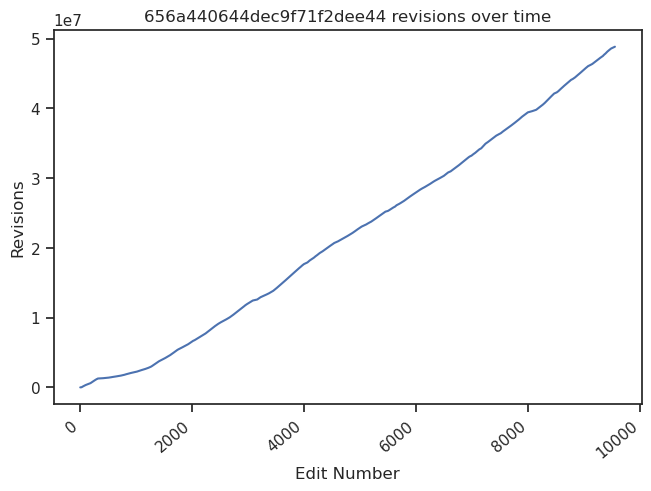

In [75]:
#df["edits"] = df["revision"].apply(len)
df["edits"] = df.apply(lambda x: count_op(None, x["revision"]), axis=1)

df["cum_edits"] = df["edits"].cumsum()

fig, ax = plt.subplots(1, 1, constrained_layout = True) 

ax = sns.lineplot(df["cum_edits"], ax=ax)
ax.set(xlabel='Edit Number', ylabel='Revisions')
ax.set_title(f"{project_id} revisions over time")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_revisions_fig.png")


# File edits across time

Currenly only showing .tex or .bib files

Index([1702674804994, 1702674805205, 1702674806190, 1702674826386,
       1702674840977, 1702674840978, 1702674841793, 1702674862535,
       1702674862684, 1702674863492,
       ...
       1708078435579, 1708078441207, 1708078441370, 1708078442624,
       1708078479786, 1708078484395, 1708078486041, 1708078487496,
       1708078517930, 1708079717776],
      dtype='int64', name='timestamp', length=9333)


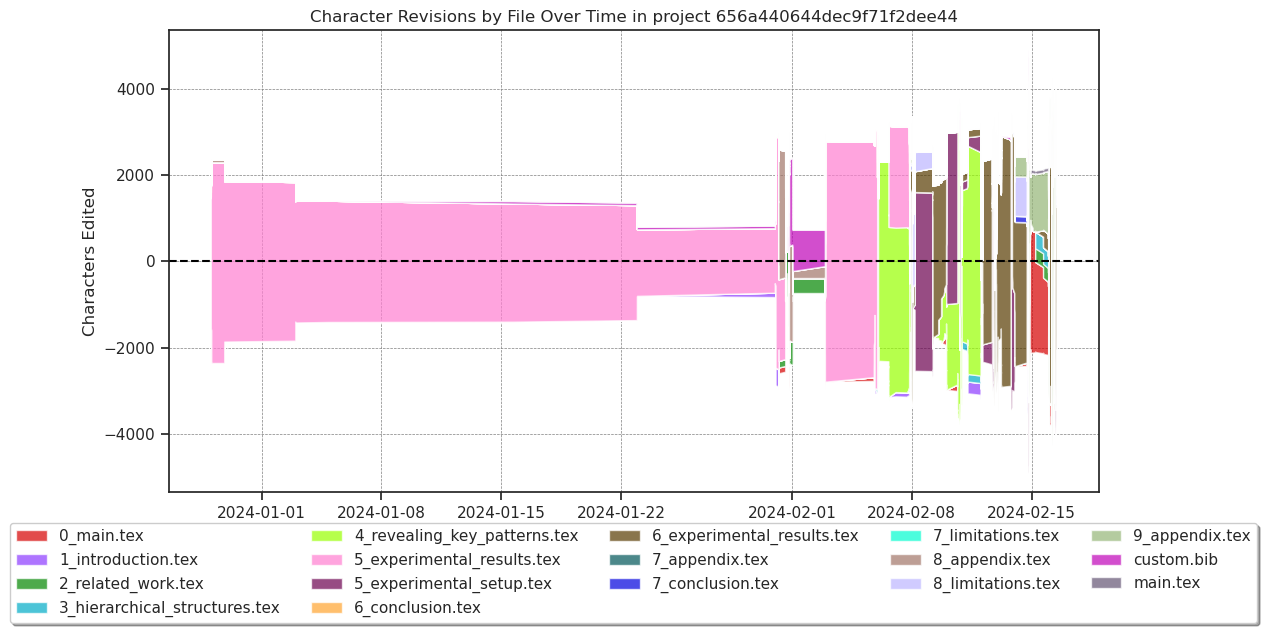

In [76]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="sym")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Characters Edited')
ax.set_title(f'Character Revisions by File Over Time in project {project_id}')
ax.set_ylim((-5350, 5350))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)
#ax.set_yscale("symlog")


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_revisions_stackplot.png")


Index([1702674804994, 1702674805205, 1702674806190, 1702674826386,
       1702674840977, 1702674840978, 1702674841793, 1702674862535,
       1702674862684, 1702674863492,
       ...
       1708078435579, 1708078441207, 1708078441370, 1708078442624,
       1708078479786, 1708078484395, 1708078486041, 1708078487496,
       1708078517930, 1708079717776],
      dtype='int64', name='timestamp', length=9333)


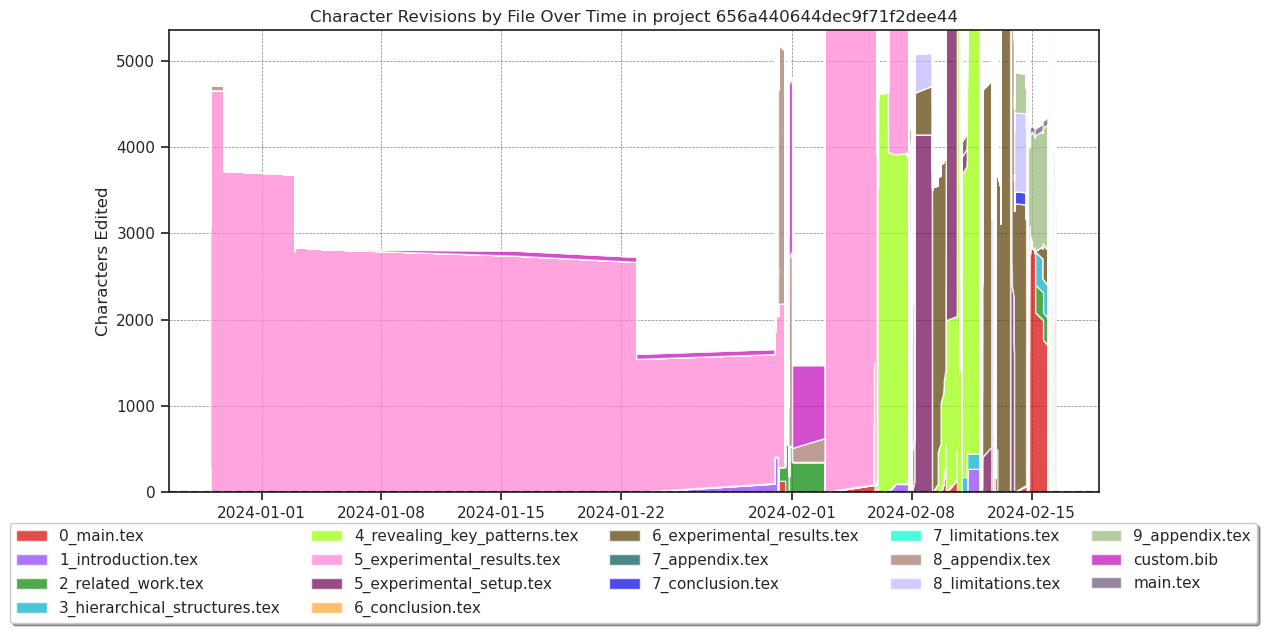

In [77]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Characters Edited')
ax.set_title(f'Character Revisions by File Over Time in project {project_id}')
ax.set_ylim((0, 5350))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)
#ax.set_yscale("symlog")


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_revisions_stackplot_updated.png")


Index([1702674804994, 1702674805205, 1702674806190, 1702674826386,
       1702674840977, 1702674840978, 1702674841793, 1702674862535,
       1702674862684, 1702674863492,
       ...
       1708078435579, 1708078441207, 1708078441370, 1708078442624,
       1708078479786, 1708078484395, 1708078486041, 1708078487496,
       1708078517930, 1708079717776],
      dtype='int64', name='timestamp', length=9333)


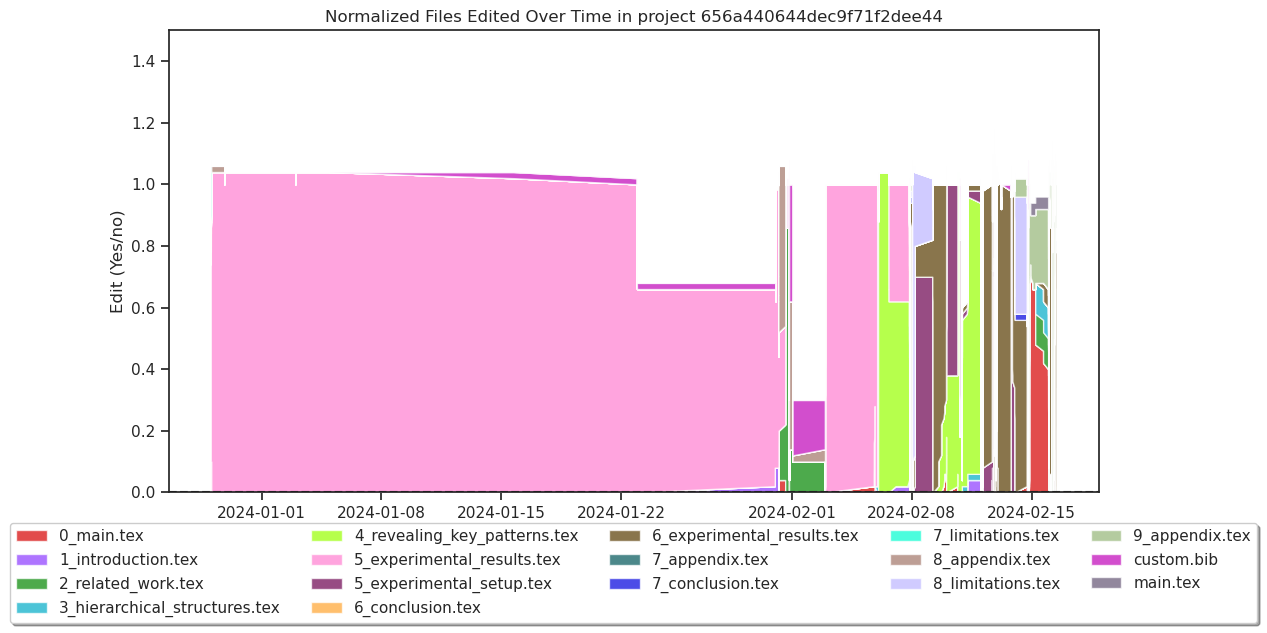

In [78]:
pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="size", fill_value=0)

relevant_files = [col for col in pivot_df.columns if '.tex' in col or '.bib' in col]

pivot_df = pivot_df[relevant_files]
window_size = 50  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_title(f'Normalized Files Edited Over Time in project {project_id}')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit (Yes/no)')
#ax.set_title('Edit (Yes/no)')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_file_edits_stackplot.png")

In [79]:
import diff_match_patch as dmp_module

dmp = dmp_module.diff_match_patch()

state
Typing      8275
Paste        637
Copy         432
Cut          116
UndoRedo      75
Switch         9
Scroll         1
Name: count, dtype: int64


/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



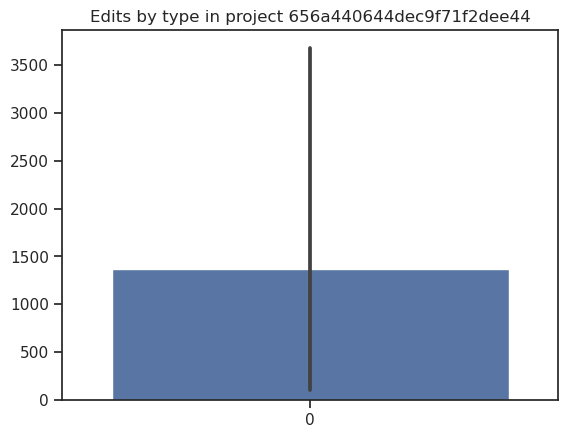

In [80]:
data = df["state"].value_counts()
print(data)
sns.barplot(data).set_title(f'Edits by type in project {project_id}')

fig.savefig(f"figures/{project_id}_edits_by_type.png")



In [81]:
idx = 12

print(df.iloc[idx]["state"])
print(df.iloc[idx]["file"])
print(df.iloc[idx]["text"])
print(df.iloc[idx]["revision"])
print("\nLen:", len(df.iloc[idx]["revision"]))
df.head()

Typing
7_limitations.tex
\section{Limitation}\label{sec:limitation}
Discourse parser 
[[0, '\\section{Limitation}\\label{sec:limitation}\nDiscourse '], [1, 'parser ']]

Len: 2


,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,clipboard,changes,cb,line_counts,edits,cum_edits
0,657cc175699d8f6253cb2f7d,1702674804994,\section{Constructing ``TenPageStories'' Datas...,"[[0, ], [4, \section{Constructing ``TenPageSto...",Copy,1,Zae Myung,656a440644dec9f71f2dee44,7_appendix.tex,"[1, 2]",Copy,"[(1,0), \section{Constructing ``TenPageStories...",NaN,NaN,2,202,202
1,657cc175699d8f6253cb2f7e,1702674805205,\section{Constructing ``TenPageStories'' Datas...,"[[0, \section{Constructing ``TenPageStories'' ...",Paste,2,Zae Myung,656a440644dec9f71f2dee44,7_appendix.tex,"[1, 2, 3]",Paste,\section{Constructing ``TenPageStories'' Datas...,"[(2,0) \section{Constructing ``TenPageStories'...",NaN,3,284,486
2,657cc176699d8f6253cb2f7f,1702674806190,\section{Constructing ``TenPageStories'' Datas...,"[[0, \section{Constructing ``TenPageStories'' ...",Typing,1,Zae Myung,656a440644dec9f71f2dee44,7_appendix.tex,"[1, 2]",Typing,NaN,"[(1,1), section{Constructing ``TenPageStories'...",NaN,2,284,770
3,657cc18a699d8f6253cb2f80,1702674826386,\section{Conclusion}\label{sec:conclusion}\n,"[[0, ], [4, \section{Conclusion}\label{sec:con...",Copy,1,Zae Myung,656a440644dec9f71f2dee44,6_conclusion.tex,"[1, 2]",Copy,"[(1,0), \section{Conclusion}\label{sec:conclus...",NaN,NaN,2,43,813
4,657cc199699d8f6253cb2f81,1702674840978,\section{Limitation}\label{sec:limitation}\n\n,"[[0, \section{Limitation}\label{sec:limitation...",Typing,2,Zae Myung,656a440644dec9f71f2dee44,7_limitations.tex,"[1, 2, 3]",Typing,NaN,"[(2,0), \n---added]",NaN,3,44,857


In [82]:
import re

def get_section_edited(text, line, editingLines):
    edit_line = int(line)

    matches = list(re.finditer("\\\\section", text))

    if not matches:
        return None

    end = matches[-1].start()
    # -1 so a failed 'rfind' maps to the first line.
    newline_table = {-1: 0}
    for i, m in enumerate(re.finditer('\\n', text), 1):
        # Don't find newlines past our last match.
        offset = m.start()
        if offset > end:
            break
        newline_table[offset] = i

    matches_idx = []
    
    for m in matches:
        newline_offset = text.rfind('\n', 0, m.start())
        newline_end = text.find('\n', m.end())  # '-1' gracefully uses the end.
        line = text[newline_offset + 1:newline_end]
        line_number = newline_table[newline_offset]
        #print (line_number, line)

        matches_idx.append((line_number, line))

    if (len(matches_idx) == 0):
        #print("no matches", matches_idx)
        return None
    elif (edit_line < matches_idx[0][0]):
        return "no section"
        #raise Exception("too early")
    else:
        #print("edit_line", edit_line, "output:", next(((line_number, line) for (line_number, line) in matches_idx if line_number < edit_line), 0))
        string = next((line for (line_number, line) in matches_idx if line_number < edit_line), 0)
        if (isinstance(string, str)):
            return string[string.find("{")+1:string.find("}")]
        else:
            return None
        

    

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



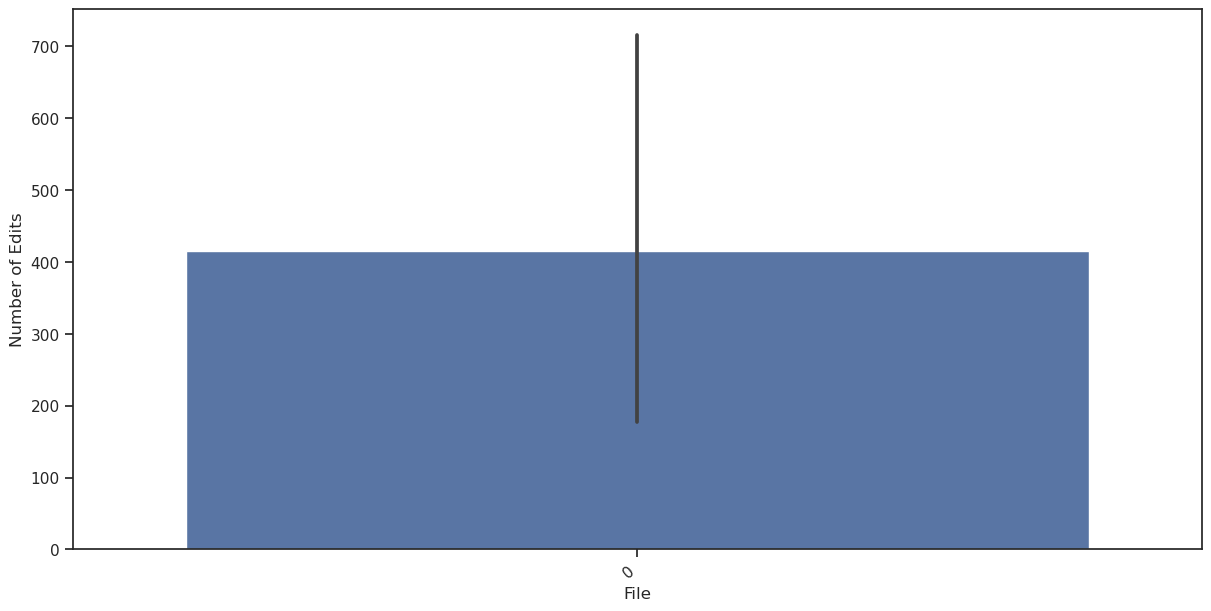

In [83]:
fig, (ax1) = plt.subplots(1, 1, constrained_layout = True,  figsize=(12,6)) 

ax1 = sns.barplot(df["file"].value_counts(), ax=ax1)
ax1.set(xlabel='File', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")

fig.savefig(f"figures/{project_id}_edits_by_file.png")



In [84]:
# can manually check this to see if it is the one that you want
main_filename = df["file"].value_counts().idxmax()

print(main_filename)

df_main = df.loc[df["file"] == main_filename].reset_index()

idx = 2

state = df_main.iloc[idx]["state"]
fname = df_main.iloc[idx]["file"]
text = df_main.iloc[idx]["text"]
changes = df_main.iloc[idx]["changes"]
revision = df_main.iloc[idx]["revision"]
editingLines = df_main.iloc[idx]["editingLines"]
line = df_main.iloc[idx]["line"]



print("length", len(text))
print("total lines", text.count("\n") + 1)
print("also total lines", len(editingLines))
print("absolute line", line)

print("\n\n\n")
get_section_edited(text, line, editingLines)

6_experimental_results.tex
length 5174
total lines 83
also total lines 83
absolute line 118






def recreate_text(revision_arr):

In [85]:
def recreate_text(revision_arr):
    text = ""
    for diff in revision_arr:
        op, data = diff[:2]
        
        if op == 0 or op == 1:
            text += data
        elif op == 2:
            raise Exception("illegal operations in diff")

    return text
        

/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/seaborn/categorical.py:486: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



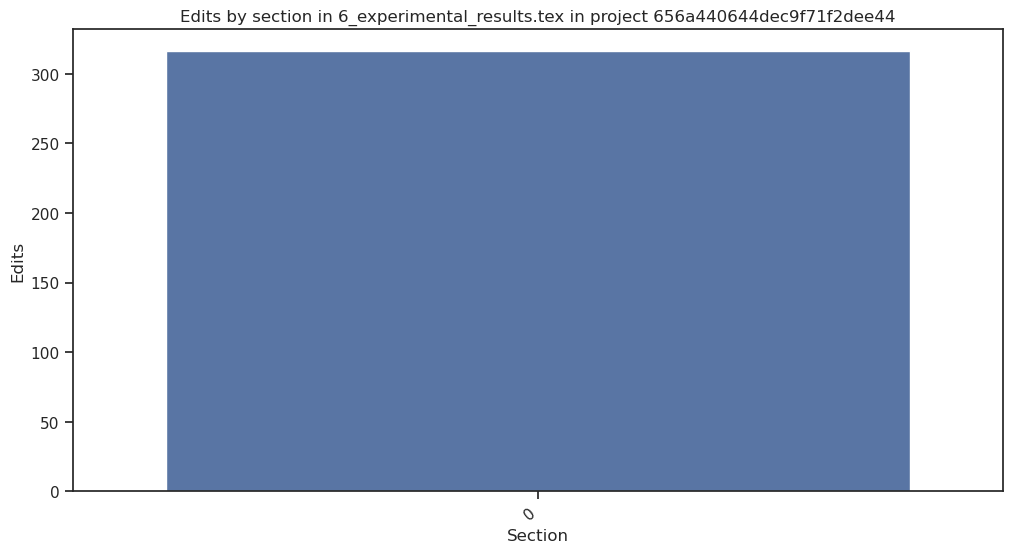

In [86]:
df_main["full_text"] = df_main.apply(lambda x: recreate_text(x["revision"]), axis=1)

df_main["section"] = df_main.apply(lambda x: get_section_edited(x["full_text"], x["line"], x["editingLines"]), axis=1)

fig, ax = plt.subplots(figsize=(12, 6)) 

sns.barplot(df_main["section"].value_counts(), ax=ax)
ax.set_title(f'Edits by section in {main_filename} in project {project_id}')
ax.set(xlabel='Section', ylabel='Edits')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

df_main.head()

fig.savefig(f"figures/{project_id}_edits_by_section_in_file.png")


section        Results
timestamp             
1707602813533        1
1707706397482        1
1707706426210        1
1707706426387        1
1707706426741        1
Index([1707602813533, 1707706397482, 1707706426210, 1707706426387,
       1707706426741, 1707706513101, 1707706513868, 1707762308600,
       1707762313179, 1707762361486,
       ...
       1708073953625, 1708075032834, 1708075044056, 1708075080526,
       1708075110585, 1708075110786, 1708075123693, 1708075132843,
       1708075135425, 1708075136294],
      dtype='int64', name='timestamp', length=297)


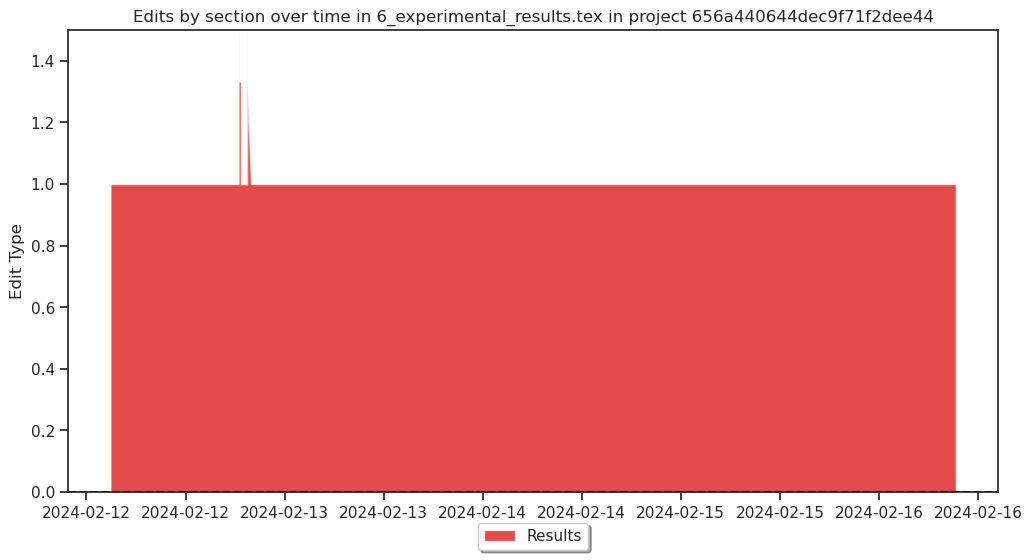

In [87]:
pivot_df = pd.pivot_table(df_main, index="timestamp", columns="section", aggfunc="size", fill_value=0)
print(pivot_df.head())

window_size = 3  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

print(pivot_df.index)
pivot_df.index = pd.to_datetime(pivot_df.index, unit="ms")

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit Type')
#ax.set_yticklabels([])
ax.set_title(f'Edits by section over time in {main_filename} in project {project_id}')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_edits_by_section_over_time.png")


In [88]:
#cb_df = df.loc[df["cb"].notnull()]
#cb_df = df.loc[df["message"].isin(["paste", "Paste"])]
df_main["cb_counts"] =  df_main["changes"].apply(lambda x: 0 if type(x) is not str else len(x))
df_main.head()



,index,_id,timestamp,text,revision,state,line,username,project,file,...,message,clipboard,changes,cb,line_counts,edits,cum_edits,full_text,section,cb_counts
0,2648,65c3efc1888271bc086d1a81,1707339712503,Figure \ref{fig:found_motifs} shows bar plots ...,"[[-1, W], [1, Figur], [0, e ], [1, \ref{fig:fo...",Typing,54,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(54,0), W---deleted, (54,307), & S---deleted,...",NaN,74,8063,9952890,Figure \ref{fig:found_motifs} shows bar plots ...,None,0
1,2676,65c3f0bd888271bc086d1a9d,1707339964326,Figure \ref{fig:proportion_edge_label_m3} show...,"[[-1, \sect], [1, F], [0, i], [-1, on{Expe], [...",Typing,118,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(118,0), \sect---deleted, (118,114), and---de...",NaN,83,8770,10088776,Figure \ref{fig:proportion_edge_label_m3} show...,None,0
2,2677,65c3f0c4888271bc086d1a9e,1707339971675,Figure \ref{fig:proportion_edge_label_m3} show...,"[[0, Figure \ref{fig:proportion_edge_label_m3}...",Typing,118,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(118,83), \dkto->to, (118,120), }---deleted, ...",NaN,83,5183,10093959,Figure \ref{fig:proportion_edge_label_m3} show...,None,0
3,2678,65c40e47888271bc086d1a9f,1707347526692,"\dk{But, then why not simply using GNNs? If di...","[[0, \dk{But, then why not simply using GNNs? ...",Typing,112,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(112,0), \dk{Can we move the paragraph below ...",NaN,63,4676,10098635,"\dk{But, then why not simply using GNNs? If di...",None,0
4,2679,65c40e47888271bc086d1aa0,1707347527054,"\dk{But, then why not simply using GNNs? If di...","[[0, \dk{But, then why not simply using GNNs? ...",Typing,111,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(111,0), \n---deleted]",NaN,62,4631,10103266,"\dk{But, then why not simply using GNNs? If di...",None,0


0       0
1       0
2       0
3       0
4       0
       ..
2737    0
2738    0
2739    0
2740    0
2741    0
Name: cb_counts, Length: 2742, dtype: int64


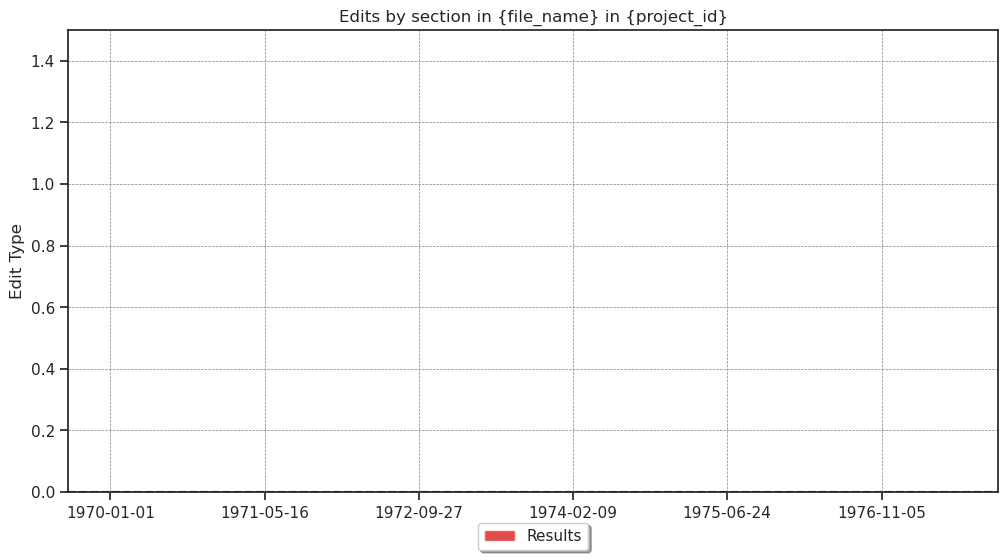

In [89]:
fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

ax.set_prop_cycle('color', colors)

print(df_main["cb_counts"])


ax.stackplot(df_main.index, df_main["cb_counts"], alpha=0.7, baseline="zero")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Edit Type')
#ax.set_yticklabels([])
ax.set_title('Edits by section in {file_name} in {project_id}')
ax.set_ylim((0, 1.5))
ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)



ax.legend(pivot_df.columns,loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_edits_by_section_in_file.png")


In [90]:
df_main.head()

,index,_id,timestamp,text,revision,state,line,username,project,file,...,message,clipboard,changes,cb,line_counts,edits,cum_edits,full_text,section,cb_counts
0,2648,65c3efc1888271bc086d1a81,1707339712503,Figure \ref{fig:found_motifs} shows bar plots ...,"[[-1, W], [1, Figur], [0, e ], [1, \ref{fig:fo...",Typing,54,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(54,0), W---deleted, (54,307), & S---deleted,...",NaN,74,8063,9952890,Figure \ref{fig:found_motifs} shows bar plots ...,None,0
1,2676,65c3f0bd888271bc086d1a9d,1707339964326,Figure \ref{fig:proportion_edge_label_m3} show...,"[[-1, \sect], [1, F], [0, i], [-1, on{Expe], [...",Typing,118,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(118,0), \sect---deleted, (118,114), and---de...",NaN,83,8770,10088776,Figure \ref{fig:proportion_edge_label_m3} show...,None,0
2,2677,65c3f0c4888271bc086d1a9e,1707339971675,Figure \ref{fig:proportion_edge_label_m3} show...,"[[0, Figure \ref{fig:proportion_edge_label_m3}...",Typing,118,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(118,83), \dkto->to, (118,120), }---deleted, ...",NaN,83,5183,10093959,Figure \ref{fig:proportion_edge_label_m3} show...,None,0
3,2678,65c40e47888271bc086d1a9f,1707347526692,"\dk{But, then why not simply using GNNs? If di...","[[0, \dk{But, then why not simply using GNNs? ...",Typing,112,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(112,0), \dk{Can we move the paragraph below ...",NaN,63,4676,10098635,"\dk{But, then why not simply using GNNs? If di...",None,0
4,2679,65c40e47888271bc086d1aa0,1707347527054,"\dk{But, then why not simply using GNNs? If di...","[[0, \dk{But, then why not simply using GNNs? ...",Typing,111,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,Typing,NaN,"[(111,0), \n---deleted]",NaN,62,4631,10103266,"\dk{But, then why not simply using GNNs? If di...",None,0


In [91]:
df_main["additions"] = df_main.apply(lambda x: count_op(1, x["revision"]), axis=1)
df_main["deletions"] = df_main.apply(lambda x: count_op(-1, x["revision"]), axis=1)
df_main.head()

,index,_id,timestamp,text,revision,state,line,username,project,file,...,changes,cb,line_counts,edits,cum_edits,full_text,section,cb_counts,additions,deletions
0,2648,65c3efc1888271bc086d1a81,1707339712503,Figure \ref{fig:found_motifs} shows bar plots ...,"[[-1, W], [1, Figur], [0, e ], [1, \ref{fig:fo...",Typing,54,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,"[(54,0), W---deleted, (54,307), & S---deleted,...",NaN,74,8063,9952890,Figure \ref{fig:found_motifs} shows bar plots ...,None,0,3942,-2329
1,2676,65c3f0bd888271bc086d1a9d,1707339964326,Figure \ref{fig:proportion_edge_label_m3} show...,"[[-1, \sect], [1, F], [0, i], [-1, on{Expe], [...",Typing,118,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,"[(118,0), \sect---deleted, (118,114), and---de...",NaN,83,8770,10088776,Figure \ref{fig:proportion_edge_label_m3} show...,None,0,3250,-3587
2,2677,65c3f0c4888271bc086d1a9e,1707339971675,Figure \ref{fig:proportion_edge_label_m3} show...,"[[0, Figure \ref{fig:proportion_edge_label_m3}...",Typing,118,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,"[(118,83), \dkto->to, (118,120), }---deleted, ...",NaN,83,5183,10093959,Figure \ref{fig:proportion_edge_label_m3} show...,None,0,0,-9
3,2678,65c40e47888271bc086d1a9f,1707347526692,"\dk{But, then why not simply using GNNs? If di...","[[0, \dk{But, then why not simply using GNNs? ...",Typing,112,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,"[(112,0), \dk{Can we move the paragraph below ...",NaN,63,4676,10098635,"\dk{But, then why not simply using GNNs? If di...",None,0,0,-45
4,2679,65c40e47888271bc086d1aa0,1707347527054,"\dk{But, then why not simply using GNNs? If di...","[[0, \dk{But, then why not simply using GNNs? ...",Typing,111,Zae,656a440644dec9f71f2dee44,6_experimental_results.tex,...,"[(111,0), \n---deleted]",NaN,62,4631,10103266,"\dk{But, then why not simply using GNNs? If di...",None,0,0,-1


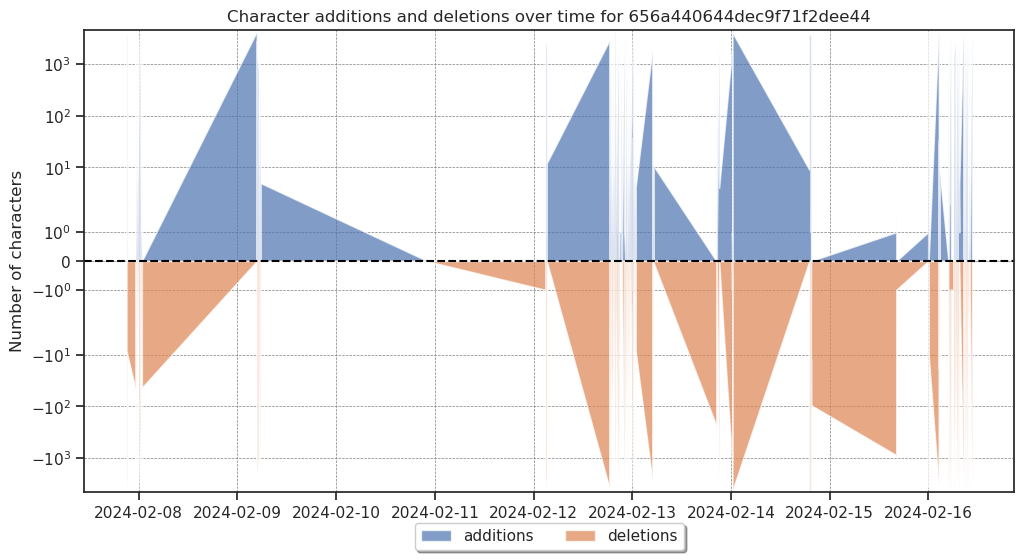

In [92]:
#pivot_df = pd.pivot_table(df1, index="timestamp", values="additions", aggfunc="size", fill_value=0)


df_main.index = pd.to_datetime(df_main["timestamp"], unit="ms")

#window_size = 1  # Adjust the window size as needed
#df1[["additions", "deletions"]] = df1[["additions", "deletions"]].rolling(window=window_size).mean()

fig, ax = plt.subplots(figsize=(12, 6)) 

#colors = sns.color_palette('hls', len(pivot_df.columns))
#colors = sns.color_palette(cc.glasbey, n_colors=len(pivot_df.columns))

#ax.set_prop_cycle('color', colors)

ax.stackplot(df_main.index, df_main["additions"], alpha=0.7, baseline="zero")
ax.stackplot(df_main.index, df_main["deletions"], alpha=0.7, baseline="zero")


# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Number of characters')
ax.set_title(f'Character additions and deletions over time for {project_id}')
ax.set_yscale("symlog")
ax.set_ylim((-4500, 4500))

ax.axhline(0, color="black", ls="--");
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)


ax.legend(df_main[["additions", "deletions"]],loc='upper center', bbox_to_anchor=(0.5, -0.05),fancybox=True, shadow=True, ncol=5)

fig.savefig(f"figures/{project_id}_character_additions_deletions_over_time.png")


In [93]:
def check(df):
    if (df["file"] == df["next_file"]):
        return "null"
    else:
        return df["next_file"]

df.head()
df["next_file"] = df["file"].shift(1)
df["next_file"] = df.apply(check, axis = 1)

In [94]:
#df["next_file"].value_counts()
import plotly as px

#labels = list(i for i in df["next_file"].unique() if i != None and i != "null")

labels = [col for col in df["next_file"].unique() if (col != None and col != "null") and ('.tex' in col or '.bib' in col)]


n_colors = int(len(labels))
colors = px.colors.sample_colorscale("turbo", [n/(n_colors -1) for n in range(n_colors)])
colors += colors


source = []
target = []
value = []
line_colors = []

for start_idx, start in enumerate(labels):
    for end_idx, end in enumerate(labels):
        if (start == end):
            # this one should already by filtered
            continue

        volume = len(df.loc[(df['file'] == start) & (df['next_file'] == end)])

        if (volume <= 0.01):
            continue
        
        source.append(start_idx)
        target.append(end_idx + len(labels))
        value.append(volume)
        line_colors.append(colors[start_idx])

labels += labels




        

In [95]:
for i in range(len(line_colors)):
    line_colors[i] = line_colors[i][0:-1] + ", 0.5)"
    line_colors[i] = line_colors[i].replace("rgb", "rgba")
    print(line_colors[i])
    

rgba(63, 63, 157, 0.5)
rgba(63, 63, 157, 0.5)
rgba(69, 105, 220, 0.5)
rgba(62, 145, 246, 0.5)
rgba(62, 145, 246, 0.5)
rgba(62, 145, 246, 0.5)
rgba(62, 145, 246, 0.5)
rgba(62, 145, 246, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(42, 184, 232, 0.5)
rgba(30, 218, 195, 0.5)
rgba(30, 218, 195, 0.5)
rgba(30, 218, 195, 0.5)
rgba(30, 218, 195, 0.5)
rgba(51, 240, 151, 0.5)
rgba(51, 240, 151, 0.5)
rgba(51, 240, 151, 0.5)
rgba(51, 240, 151, 0.5)
rgba(51, 240, 151, 0.5)
rgba(51, 240, 151, 0.5)
rgba(105, 252, 102, 0.5)
rgba(105, 252, 102, 0.5)
rgba(105, 252, 102, 0.5)
rgba(105, 252, 102, 0.5)
rgba(105, 252, 102, 0.5)
rgba(164, 252, 59, 0.5)
rgba(164, 252, 59, 0.5)
rgba(164, 252, 59, 0.5)
rgba(164, 252, 59, 0.5)
rgba(164, 252, 59, 0.5)
rgba(164, 252, 59, 0.5)
rgba(164, 252, 59, 0.5)
rgba(203, 234, 53, 0.5)
rgba(203, 234, 53, 0.5)
rgba(203, 234

In [96]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 1),
      label = labels,
      color = colors
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value,
      color=line_colors
  ))],
    layout = dict(
        height = 800,
        width = 800
    ))

fig.update_layout(title_text="Changes in Edited files in project: " + project_id, font_size=10)
fig.write_image(f"sankey_{project_id}.png")

fig.write_image(f"figures/{project_id}_writing_flow_sankey.png")

fig.show()


